In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Loading the Spotify dataset

In [19]:
df = pd.read_csv('../Data/spotify_songs.csv')
df.head().T

,0,1,2,3,4
track_id,6f807x0ima9a1j3VPbc7VN,0r7CVbZTWZgbTCYdfa2P31,1z1Hg7Vb0AhHDiEmnDE79l,75FpbthrwQmzHlBJLuGdC7,1e8PAfcKUYoKkxPhrHqw4x
track_name,I Don't Care (with Justin Bieber) - Loud Luxur...,Memories - Dillon Francis Remix,All the Time - Don Diablo Remix,Call You Mine - Keanu Silva Remix,Someone You Loved - Future Humans Remix
track_artist,Ed Sheeran,Maroon 5,Zara Larsson,The Chainsmokers,Lewis Capaldi
track_popularity,66,67,70,60,69
track_album_id,2oCs0DGTsRO98Gh5ZSl2Cx,63rPSO264uRjW1X5E6cWv6,1HoSmj2eLcsrR0vE9gThr4,1nqYsOef1yKKuGOVchbsk6,7m7vv9wlQ4i0LFuJiE2zsQ
track_album_name,I Don't Care (with Justin Bieber) [Loud Luxury...,Memories (Dillon Francis Remix),All the Time (Don Diablo Remix),Call You Mine - The Remixes,Someone You Loved (Future Humans Remix)
track_album_release_date,2019-06-14,2019-12-13,2019-07-05,2019-07-19,2019-03-05
playlist_name,Pop Remix,Pop Remix,Pop Remix,Pop Remix,Pop Remix
playlist_id,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW,37i9dQZF1DXcZDD7cfEKhW
playlist_genre,pop,pop,pop,pop,pop


In [20]:
df.shape

(32833, 23)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

# Remove Missing Values

In [22]:
missing = pd.concat([df.isnull().sum(), 100 * df.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False)

,count,%
track_artist,5,0.015229
track_album_name,5,0.015229
track_name,5,0.015229
track_id,0,0.000000
key,0,0.000000
tempo,0,0.000000
valence,0,0.000000
liveness,0,0.000000
instrumentalness,0,0.000000
acousticness,0,0.000000


In [23]:
#There are 5 records with missing values. Since this is a small percentage, I will drop them.
df.dropna(inplace=True)
df.shape

(32828, 23)

# Create a new variable for the top genre and subgenre
### since tracks can be repeated, I will tack the most common genre

In [24]:
df['top_genre'] = df.groupby('track_id')['playlist_genre'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

df['top_subgenre'] = df.groupby('track_id')['playlist_subgenre'].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

# Create new variable for number of occurences
### There may be signal in the fact that some tracks appear accross multiple playlists or with different versions (Radio edit version, Explicit version, Deluxe version, Compilation Album)

In [25]:
df['track_occurences'] = df['track_id'].map(df['track_id'].value_counts())

# Remove duplicates based on track_id

In [26]:
df['track_id'].value_counts().head()

track_id
7BKLCZ1jbUBVqRi2FVlTVw    10
14sOS5L36385FJ3OL8hew4     9
3eekarcy7kvN4yt5ZFzltW     9
0sf12qNH5qcw8qpgymFOqD     8
7h0d2h0fUmzbs7zeFigJPn     8
Name: count, dtype: int64

In [27]:
#Closer by The Chainsmokers is duplicated 10 times because it appears in different playlists
df[df['track_id']=='7BKLCZ1jbUBVqRi2FVlTVw']

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences
133,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
1731,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,Post pop teen,222nc9tKxKhfZ2GBrOpwH3,pop,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
2478,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,Electropop Hits 2017-2020,7kyvBmlc1uSqsTL0EuNLrx,pop,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
4535,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,A Loose Definition of Indie Poptimism,4ZO0wp9G8FA3X6oYNBzda6,pop,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
7369,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,◤ Hip Hop Dance Music – Urban – Trap – Breakin...,0Hr2h94pKN8QAGVAgD6BsD,rap,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
17467,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,Tropical House Run 190 BPM,37i9dQZF1DWSTc9FdySHtz,latin,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
18358,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,4JkkvMpVl4lSioqQjeAL0q,latin,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
19770,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,4JkkvMpVl4lSioqQjeAL0q,latin,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
23784,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,4JkkvMpVl4lSioqQjeAL0q,r&b,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10
30629,7BKLCZ1jbUBVqRi2FVlTVw,Closer (feat. Halsey),The Chainsmokers,85,0rSLgV8p5FzfnqlEk4GzxE,Closer (feat. Halsey),2016-07-29,2015 songs,6UJw1egIcZVfrBmcKs5uHH,edm,...,0.0338,0.414,0.0,0.111,0.661,95.01,244960,pop,dance pop,10


In [28]:
original_rows = len(df)
print("Original df:", original_rows)

df2 = df.drop_duplicates(subset=['track_id'], keep='first')

no_dups_rows = len(df2)
print("No dups df:", no_dups_rows)
print(f"Number of records removed: {original_rows - no_dups_rows}")

Original df: 32828
No dups df: 28352
Number of records removed: 4476


# Remove duplicates based on track_name and features
## Keep the more popular track

In [29]:
check_cols = ['track_name','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms']
df2[df2.duplicated(subset=check_cols, keep=False)].sort_values(by='track_name').head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences
12103,6aNP9GlBi3VHPXl7w3Qjr9,'39 - 2011 Mix,Queen,46,1GbtB4zTqAsyfZEsm1RZfx,A Night At The Opera (2011 Remaster),1975-11-21,The Queen - La Discografia Completa,3E88dLx4fgFYY70gdGzdnB,rock,...,0.0273,0.0271,0.000,0.1110,0.373,101.626,210800,rock,album rock,1
14503,65NTcXUtOb27NHKQ4fAcw0,'39 - 2011 Mix,Queen,60,75eP8LZolyNBpqIRyB5pvB,A Night At The Opera (Deluxe Edition 2011 Rema...,1975-11-21,I didn’t know perm stood for permanent (wave),3e6gYPyrTbaB8BWgSHCt5j,rock,...,0.0273,0.0271,0.000,0.1110,0.373,101.626,210800,rock,permanent wave,1
13622,5QLHGv0DfpeXLNFo7SFEy1,1979 - Remastered 2012,The Smashing Pumpkins,74,55RhFRyQFihIyGf61MgcfV,Mellon Collie And The Infinite Sadness (Deluxe...,1995,The Sound of Permanent Wave,4EYSGTuqe9cVfSVpX4gtGv,rock,...,0.0332,0.0166,0.588,0.0513,0.964,126.879,266200,rock,permanent wave,1
14142,3Y8Ff1nH44jFywAtpgmleZ,1979 - Remastered 2012,The Smashing Pumpkins,15,4bPT6Q8ppaSNppk1kbEbLl,Mellon Collie And The Infinite Sadness (Remast...,1995-12-12,keg party jukebox,4PjiT7SWnUsTTTvKOuR76f,rock,...,0.0332,0.0166,0.588,0.0513,0.964,126.879,266200,rock,permanent wave,1
9592,29ZXwWOOLz9t5fa3eT3i7T,223's (feat. 9lokknine),YNW Melly,77,5xq6RMHNIBA73qld03dR6V,Melly vs. Melvin,2019-11-22,GANGSTA RAP,3DUkl93JjPdOyX83SJr5ms,rap,...,0.3330,0.0388,0.000,0.0924,0.695,94.998,176640,rap,gangster rap,1


In [30]:
original_rows = len(df2)
print("Original df:", original_rows)

df3 = df2.sort_values(by='track_popularity', ascending=False)
df3 = df3.drop_duplicates(subset=check_cols, keep='first')

no_dups_rows = len(df3)
print("No dups df:", no_dups_rows)
print(f"Number of records removed: {original_rows - no_dups_rows}")

Original df: 28352
No dups df: 27734
Number of records removed: 618


# Remove duplicates based on Track Name and Artist
## Keep the more popular track

In [31]:
#These are different version of songs with very similar features
#For example: Radio edit version, Explicit version, Deluxe version, Compilation Album
check_cols = ['track_name', 'track_artist']
df3[df3.duplicated(subset=check_cols, keep=False)].sort_values(by=['track_name','track_popularity'], ascending=[True, False]).head(7)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences
6037,7kBdenpTmgWfAz9clmBcok,#1 Stunna,Big Tymers,48,7pe02mW4PQwNJkrmSup7bu,I Got That Work,2000-01-01,Hip-Hop Drive,37i9dQZF1DWUFmyho2wkQU,rap,...,0.2850,0.01760,0.003270,0.2580,0.561,89.017,281960,rap,hip hop,1
7075,5xGxl3Iux0worDz9tLbaDn,#1 Stunna,Big Tymers,0,688cR89wVSFrXVj56N59g6,I Got That Work (Explicit Version),2000-01-01,Dirty South Rap Classics by DJ HOTSAUCE,0tLHH1C4HkWEUCXXSSjbOe,rap,...,0.2840,0.01500,0.004040,0.2580,0.569,89.070,281960,rap,southern hip hop,1
8759,4xkOaSrkexMciUUogZKVTS,'Till I Collapse,Eminem,83,2cWBwpqMsDJC1ZUwz813lo,The Eminem Show,2002-05-26,Gangster Rap | 100 % Gangster,2e0d7otcM1oyecfi3zZPWk,rap,...,0.1860,0.06220,0.000000,0.0816,0.100,171.447,297787,edm,big room,2
8558,6yr8GiTHWvFfi4o6Q5ebdT,'Till I Collapse,Eminem,16,1ftvBBcu7jYIvXyt3JWB8S,The Eminem Show,2002-05-26,Gangster Rap,5joQabz9ys3XPGbSx5CaKv,rap,...,0.1970,0.07480,0.000000,0.0784,0.100,171.411,297893,rap,gangster rap,2
12213,5QTxFnGygVM4jFQiBovmRo,(Don't Fear) The Reaper,Blue Öyster Cult,75,6C9WzlQANeoD0GW5B41YJt,Agents Of Fortune,1976,The Sound of Album Rock,3yj9YnQGTdnFuKbDyXGDi6,rock,...,0.0733,0.00290,0.000211,0.2970,0.382,141.470,308120,rock,album rock,2
12783,2NL4BBBSgypHnxUKmQdYcT,(Don't Fear) The Reaper,Blue Öyster Cult,10,6NNrQJ8ojvbfFzoUjjABo4,The Essential Blue Öyster Cult,1972,Supernatural Classic Rock,6oghIlByD49KFGNmNU8GSH,rock,...,0.0609,0.00127,0.002130,0.3050,0.559,141.162,308640,rock,classic rock,2
11766,6NTqBHONQqmud0ONBzsLfZ,(Don't Fear) The Reaper,Blue Öyster Cult,7,6YOzCPyuPC92Eg44ag564g,Agents of Fortune,1976,House Of The Rising Sun,1bMYfBHYBCRHY5LGkjlpSy,rock,...,0.0593,0.00125,0.001110,0.3010,0.532,141.175,308440,rock,album rock,2


In [32]:
original_rows = len(df3)
print("Original df:", original_rows)

df4 = df3.sort_values(by='track_popularity', ascending=False)
df4 = df4.drop_duplicates(subset=check_cols, keep='first')

no_dups_rows = len(df4)
print("No dups df:", no_dups_rows)
print(f"Number of records removed: {original_rows - no_dups_rows}")

Original df: 27734
No dups df: 26226
Number of records removed: 1508


# Remix Tracks

In [33]:
# Filter tracks containing "remix" or "Remix" in the track name
remix_tracks = df4[df4['track_name'].str.contains('remix', case=False)]

# Display the first few results
print(f"Found {len(remix_tracks)} tracks with 'remix' in the name")
remix_tracks.head()

Found 1694 tracks with 'remix' in the name


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences
17796,5stPVcRqb4qixbafP9e8lt,Hola - Remix,Dalex,91,65Pp2tO1Ul66KcCmmkRGWZ,Hola (Remix),2019-11-01,LATIN POP 2020 🔥 Pop latino actual,2kKzN3kRYDzBctlaWs7CP2,latin,...,0.3110,0.4710,0.0000,0.0781,0.343,181.857,249520,latin,hip pop,5
1346,2YpeDb67231RjR0MgVLzsG,Old Town Road - Remix,Lil Nas X,90,4IRiXE5NROxknUSAUSjMoO,7 EP,2019-06-21,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,0.1020,0.0533,0.0000,0.1130,0.639,136.041,157067,latin,hip pop,4
5540,7h0d2h0fUmzbs7zeFigJPn,HIGHEST IN THE ROOM (feat. ROSALÍA & Lil Baby)...,Travis Scott,89,1Sf8GsXG32t0jNrX11xqWx,JACKBOYS,2019-12-27,RapCaviar,37i9dQZF1DX0XUsuxWHRQd,rap,...,0.0346,0.0567,0.0000,0.0992,0.114,153.131,244874,rap,gangster rap,8
1327,07Oz5StQ7GRoygNLaXs2pd,Good as Hell (feat. Ariana Grande) - Remix,Lizzo,89,1k1HuvFs562Z3CCiSYhtc1,Good as Hell (feat. Ariana Grande) [Remix],2019-10-25,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,46Cl6dmeiylK6TRGXr7hHe,pop,...,0.0645,0.2980,0.0000,0.7350,0.478,95.927,159011,pop,indie poptimism,4
546,24Yi9hE78yPEbZ4kxyoXAI,Roses - Imanbek Remix,SAINt JHN,88,3GqSdhWjmMypMwPLtzoFYs,Roses (Imanbek Remix),2019-10-09,Dance Pop Tunes,4SdfG4cPG3skmTiQLozZGh,pop,...,0.0495,0.0167,0.0105,0.3530,0.898,121.974,176840,edm,big room,4


In [34]:
# See artists with the most remixes
remix_tracks['track_artist'].value_counts().head()

track_artist
The Chainsmokers             31
Calvin Harris                22
Martin Garrix                18
Dimitri Vegas & Like Mike    13
Ed Sheeran                   13
Name: count, dtype: int64

In [35]:
# I will remove all remixes because these have similar features to the original song but may have very different popularity
original_rows = len(df4)
print("Original df:", original_rows)

df5 = df4[~df4['track_name'].str.contains('remix', case=False)]

no_dups_rows = len(df5)
print("No dups df:", no_dups_rows)
print(f"Number of records removed: {original_rows - no_dups_rows}")

Original df: 26226
No dups df: 24532
Number of records removed: 1694


# Playlist Genres

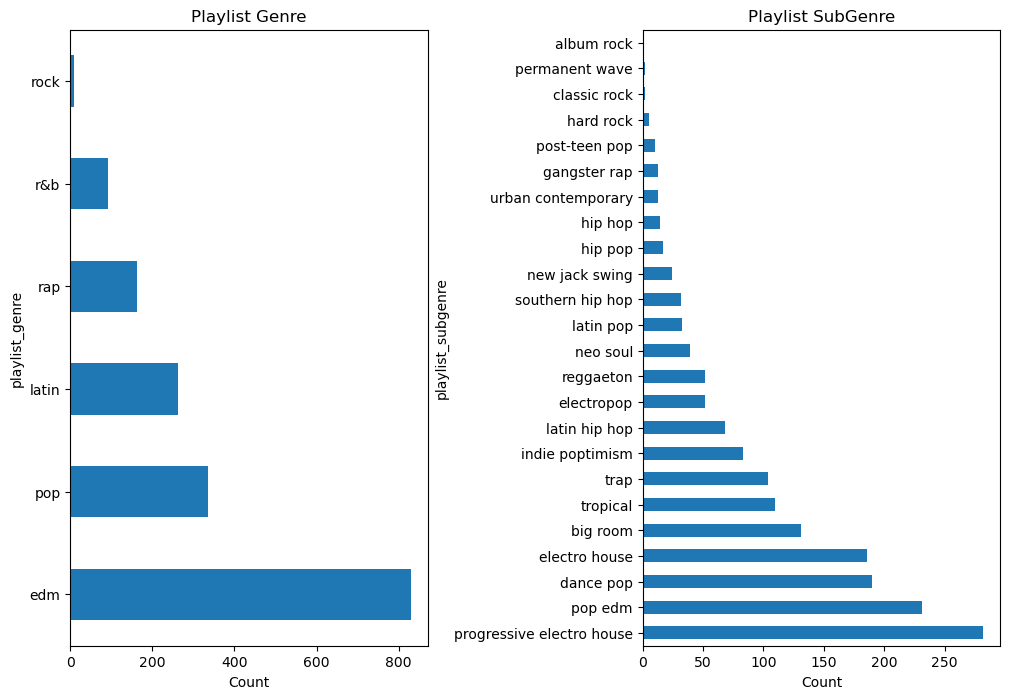

In [36]:
#What playlist genres do REMIXES fall under?
#Note that playlist genres will be excluded after cleaning so this is just for the sake of curiosity.

#Create two subplots on 1 row and 2 columns with a figsize of (12, 8)
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
remix_tracks.playlist_genre.value_counts().plot(kind='barh', ax=ax[0])
ax[0].set_title('Playlist Genre')
ax[0].set_xlabel('Count')

remix_tracks.playlist_subgenre.value_counts().plot(kind='barh', ax=ax[1])
ax[1].set_title('Playlist SubGenre')
ax[1].set_xlabel('Count')
plt.subplots_adjust(wspace=0.6);

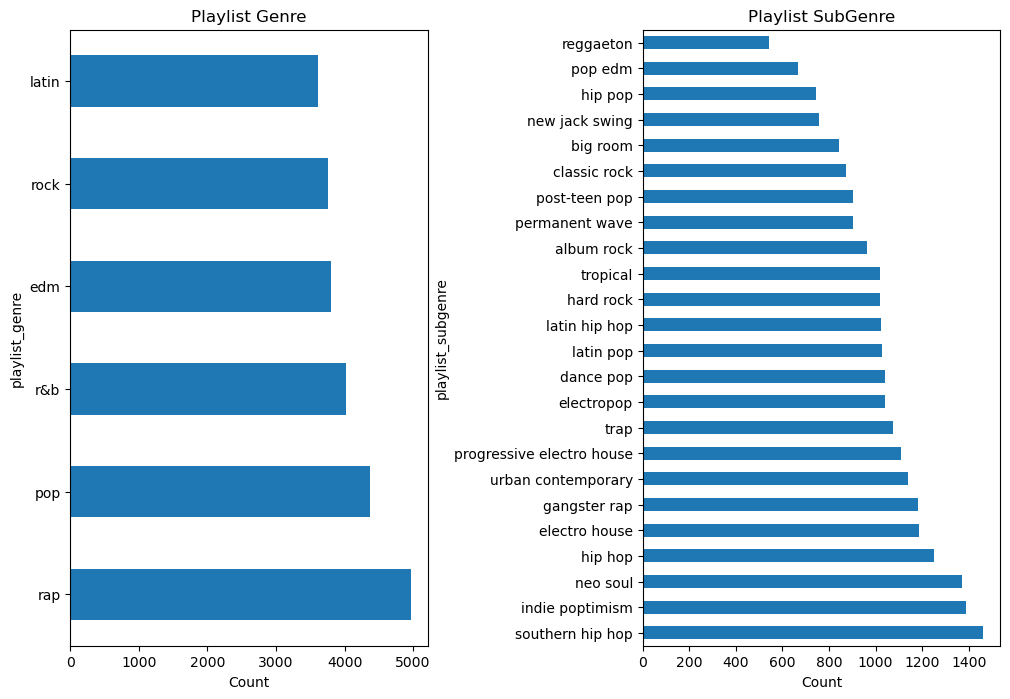

In [37]:
#What playlist genres do all tracks fall under?

#Create two subplots on 1 row and 2 columns with a figsize of (12, 8)
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
df5.playlist_genre.value_counts().plot(kind='barh', ax=ax[0])
ax[0].set_title('Playlist Genre')
ax[0].set_xlabel('Count')

df5.playlist_subgenre.value_counts().plot(kind='barh', ax=ax[1])
ax[1].set_title('Playlist SubGenre')
ax[1].set_xlabel('Count')
plt.subplots_adjust(wspace=0.6);

# Popularity

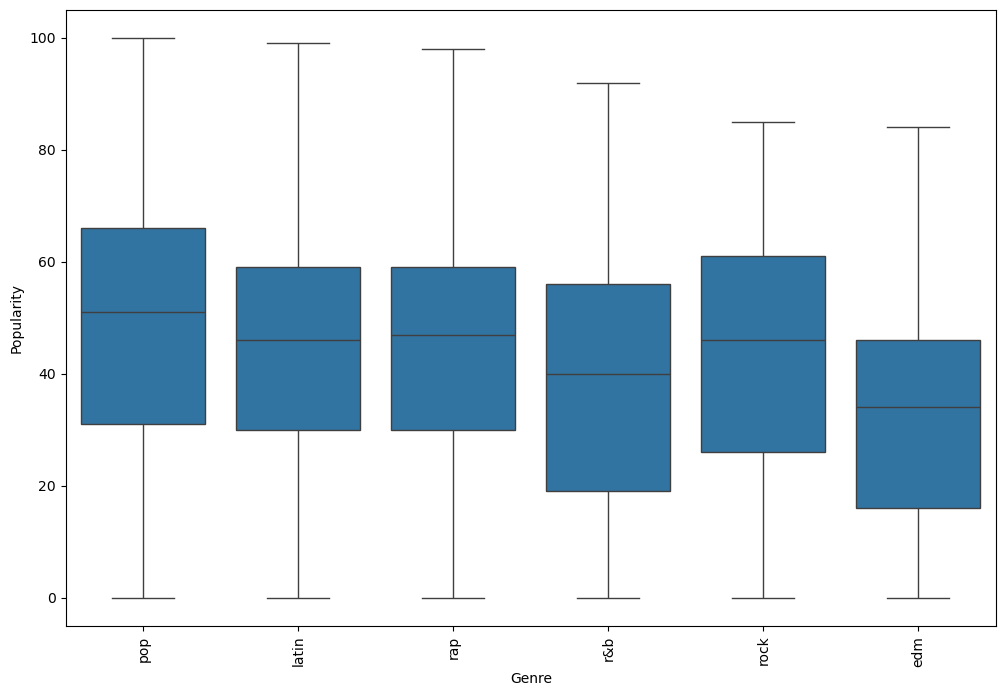

In [38]:
#pop songs have the highest median popularity while edm has the lowest

plt.subplots(figsize=(12, 8))
sns.boxplot(x='playlist_genre', y='track_popularity', data=df5)
plt.xticks(rotation='vertical')
plt.ylabel('Popularity')
plt.xlabel('Genre');

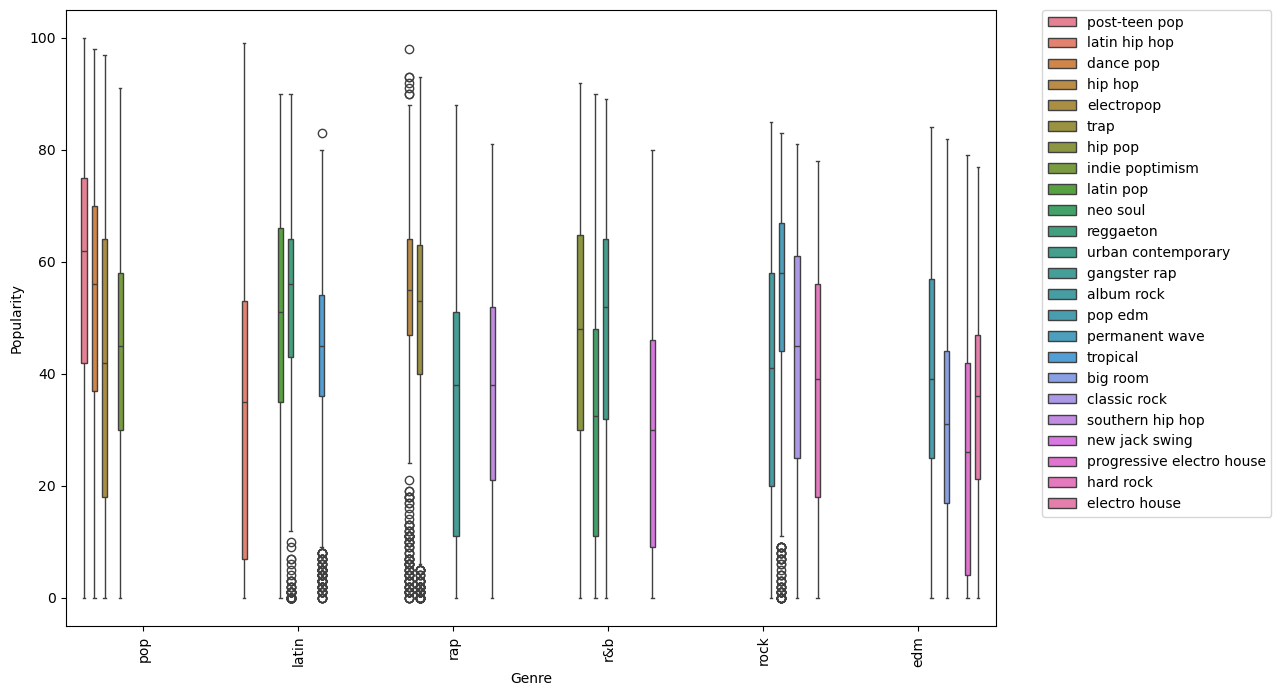

In [39]:
#Within pop, post-teen pop has the highest median popularity

plt.subplots(figsize=(12, 8))
sns.boxplot(x='playlist_genre', y='track_popularity', hue='playlist_subgenre', data=df5)

# Move the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.xticks(rotation='vertical')
plt.ylabel('Popularity')
plt.xlabel('Genre');

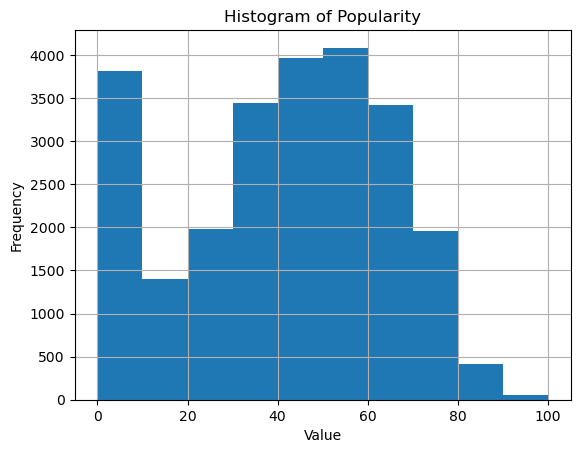

In [40]:
#Many tracks have popularity of zero. I will have take a closer look during EDA.

df5.track_popularity.hist()
plt.title("Histogram of Popularity")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# Track Release Dates

In [41]:
#There are many tracks that don't have full release date
df5[df5['track_album_release_date'].str.len() <= 7].head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences
2096,4llK75pXNWZz6KAho2Gp16,She Will Be Loved - Radio Mix,Maroon 5,80,5zClcGCSWj926AMjvBNSLc,Songs About Jane: 10th Anniversary Edition,2002,post teen pop,2ltt5ouiEO301o2jbxn30d,pop,...,0.0281,0.228,0.000000,0.0994,0.465,102.000,259453,pop,electropop,2
12230,4bHsxqR3GMrXTxEPLuK5ue,Don't Stop Believin',Journey,80,43wpzak9OmQfrjyksuGwp0,Escape,1981,The Sound of Album Rock,3yj9YnQGTdnFuKbDyXGDi6,rock,...,0.0363,0.127,0.000000,0.4470,0.514,118.852,250987,rock,album rock,3
3804,2JzZzZUQj3Qff7wapcbKjc,See You Again (feat. Charlie Puth),Wiz Khalifa,80,5FXIqS1XqbpfOKNoi5VUwS,See You Again (feat. Charlie Puth),2015,10er Playlist,1kEczIkZH8IgaWT2BiApxZ,pop,...,0.0815,0.369,0.000001,0.0649,0.283,80.025,229526,edm,electropop,2
12274,2RlgNHKcydI9sayD2Df2xp,Mr. Blue Sky,Electric Light Orchestra,79,3usnShwygMXVZB4IV5dwnU,Out of the Blue,1977,The Sound of Album Rock,3yj9YnQGTdnFuKbDyXGDi6,rock,...,0.0328,0.652,0.000004,0.2480,0.477,177.784,303373,rock,album rock,2
7614,3yrSvpt2l1xhsV9Em88Pul,Brown Eyed Girl,Van Morrison,79,7dsWupQRlFuhG8FGiQAUjC,Blowin' Your Mind!,1967-09,Southern Soul BBQ Mix,3nTS97zUqxJBQeiXNRs963,rap,...,0.0376,0.182,0.000000,0.4070,0.907,150.572,183307,rock,album rock,3


In [42]:
# Define a function to supply dates with random month and day when not provided
def parse_date_with_random(date_str):
    try:
        # Check if the date_str is already a timestamp or NaT
        if pd.isna(date_str):
            return pd.NaT
            
        date_str = str(date_str).strip()
        
        if len(date_str) == 4:  # Just year (YYYY)
            random_month = random.randint(1, 12)
            random_day = random.randint(1, 28)
            return pd.to_datetime(f"{date_str}-{random_month:02d}-{random_day:02d}")
            
        elif len(date_str) == 7:  # Year-month (YYYY-MM)
            year_month = pd.to_datetime(date_str + "-01")
            random_day = random.randint(1, 28)
            return pd.to_datetime(f"{date_str}-{random_day:02d}")
            
        else:  # Full date or other format
            return pd.to_datetime(date_str, errors='coerce')
    except:
        print(f"Error parsing {date_str}: {e}")
        return pd.NaT

# Apply the custom parsing function
df5['track_album_release_date'] = df5['track_album_release_date'].apply(parse_date_with_random)

# Extract year, month, day for additional analysis
df5['release_year'] = df5['track_album_release_date'].dt.year.astype(pd.Int64Dtype())
df5['release_month'] = df5['track_album_release_date'].dt.month.astype(pd.Int64Dtype())
df5['release_day'] = df5['track_album_release_date'].dt.day.astype(pd.Int64Dtype())

C:\Users\omega\AppData\Local\Temp\ipykernel_31772\1080447768.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['track_album_release_date'] = df5['track_album_release_date'].apply(parse_date_with_random)
C:\Users\omega\AppData\Local\Temp\ipykernel_31772\1080447768.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['release_year'] = df5['track_album_release_date'].dt.year.astype(pd.Int64Dtype())
C:\Users\omega\AppData\Local\Temp\ipykernel_31772\1080447768.py:31: SettingWithCopyWarning: 
A value i

In [43]:
#Confirm that these 3 tracks now have proper release_dates
df5[df5['track_id'].isin(['4llK75pXNWZz6KAho2Gp16','4bHsxqR3GMrXTxEPLuK5ue','2JzZzZUQj3Qff7wapcbKjc'])]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences,release_year,release_month,release_day
2096,4llK75pXNWZz6KAho2Gp16,She Will Be Loved - Radio Mix,Maroon 5,80,5zClcGCSWj926AMjvBNSLc,Songs About Jane: 10th Anniversary Edition,2002-01-06,post teen pop,2ltt5ouiEO301o2jbxn30d,pop,...,0.0994,0.465,102.000,259453,pop,electropop,2,2002,1,6
12230,4bHsxqR3GMrXTxEPLuK5ue,Don't Stop Believin',Journey,80,43wpzak9OmQfrjyksuGwp0,Escape,1981-06-08,The Sound of Album Rock,3yj9YnQGTdnFuKbDyXGDi6,rock,...,0.4470,0.514,118.852,250987,rock,album rock,3,1981,6,8
3804,2JzZzZUQj3Qff7wapcbKjc,See You Again (feat. Charlie Puth),Wiz Khalifa,80,5FXIqS1XqbpfOKNoi5VUwS,See You Again (feat. Charlie Puth),2015-02-27,10er Playlist,1kEczIkZH8IgaWT2BiApxZ,pop,...,0.0649,0.283,80.025,229526,edm,electropop,2,2015,2,27


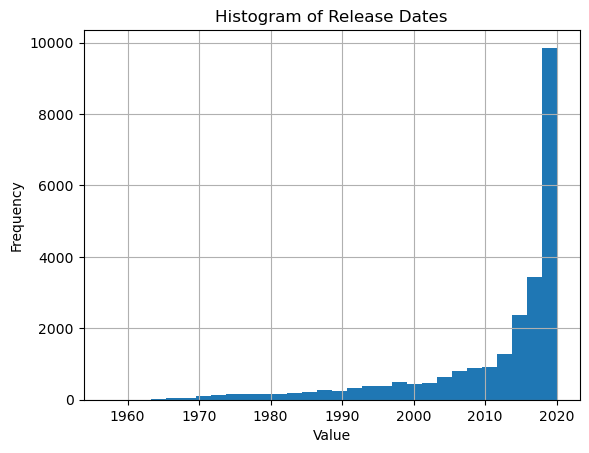

In [44]:
#Release dates are mostly from 2019
df5.track_album_release_date.hist(bins=30)
plt.title("Histogram of Release Dates")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [45]:
# Get the top 5 counts for each release date column
year_counts = df5['release_year'].value_counts().head(5)
month_counts = df5['release_month'].value_counts().head(5)
day_counts = df5['release_day'].value_counts().head(5)

# Display the results
print("Top 5 Release Years:")
print(year_counts)
print("\nTop 5 Release Months:")
print(month_counts)
print("\nTop 5 Release Days:")
print(day_counts)

Top 5 Release Years:
release_year
2019    6706
2018    2556
2017    1845
2016    1502
2015    1260
Name: count, dtype: Int64

Top 5 Release Months:
release_month
1     3938
11    2594
10    2448
9     2052
12    1952
Name: count, dtype: Int64

Top 5 Release Days:
release_day
1     3164
20     893
13     849
10     846
25     822
Name: count, dtype: Int64


# Drop Unecessary Columns

In [46]:
cols_to_drop = ['track_id', 'track_album_id','playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']

In [47]:
df_cleaned = df5.drop(cols_to_drop, axis=1)

# Histogram of all features

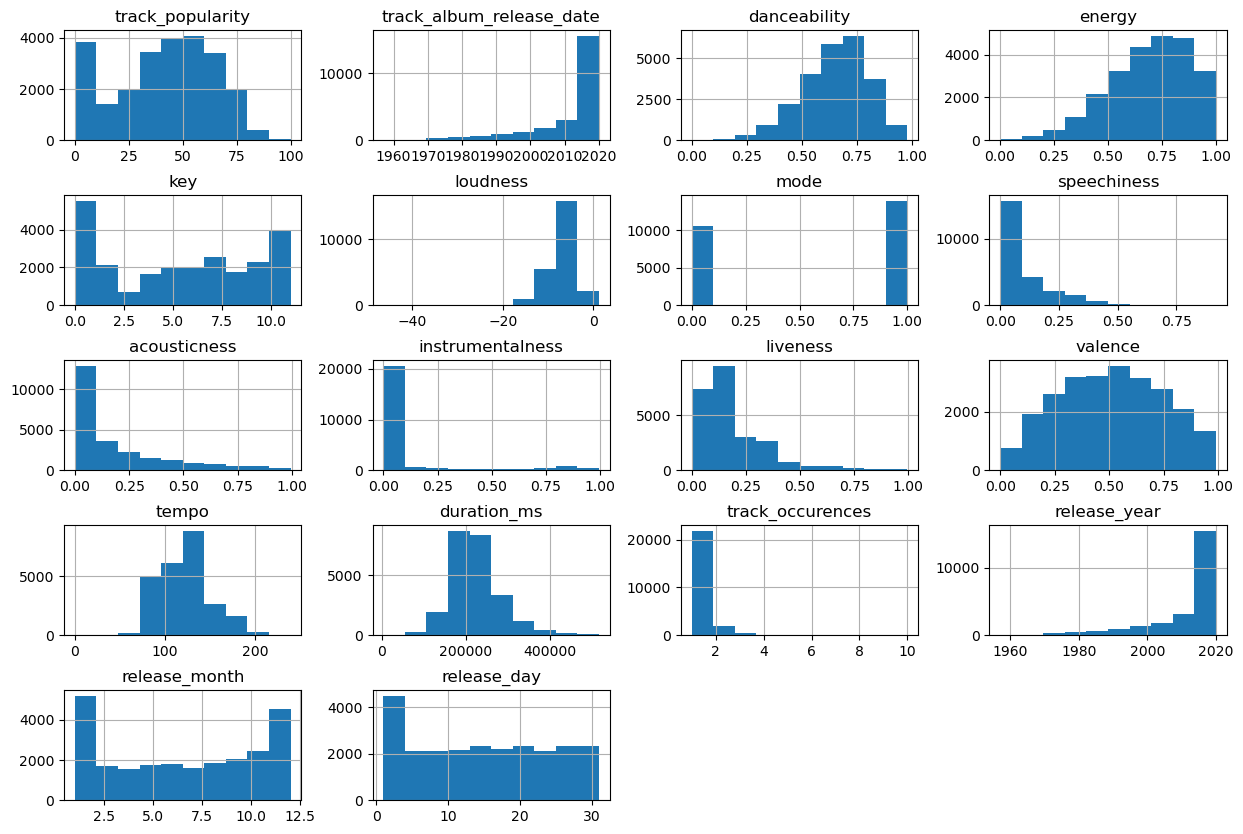

In [48]:
#Plot histograms of all numeric features to look for outliers
df_cleaned.hist(figsize=(15,10))
plt.subplots_adjust(hspace=0.5);

In [49]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24532 entries, 1551 to 31430
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_name                24532 non-null  object        
 1   track_artist              24532 non-null  object        
 2   track_popularity          24532 non-null  int64         
 3   track_album_name          24532 non-null  object        
 4   track_album_release_date  24532 non-null  datetime64[ns]
 5   danceability              24532 non-null  float64       
 6   energy                    24532 non-null  float64       
 7   key                       24532 non-null  int64         
 8   loudness                  24532 non-null  float64       
 9   mode                      24532 non-null  int64         
 10  speechiness               24532 non-null  float64       
 11  acousticness              24532 non-null  float64       
 12  instrumentalness    

# Export Dataset

In [50]:
# save the data to a new csv file
filepath = '..\Data\spotify_songs_cleaned.csv'
df_cleaned.to_csv(filepath, index=False)

# Summary
-Removed 5 tracks due to missing values
<br>-Removed 4476 duplicates based on track_id
<br>-Removed 618 duplicates based on track_id and sound features (loudness, valence, tempo, etc)
<br>-Removed 1508 duplicates based on track_name and artist_name
<br>-Removed 1694 remix tracks
<br>-Explored playlist genres
<br>-Converted track_album_release_date to datetime and filled in any missing dates with random numbers
<br>-Created 3 new columns from for release_year, release_month, and release_day
<br>-Dropped columns not needed for analysis: track_id, track_album_id, playlist_name, playlist_id, playlist_genre, playlist_subgenre
<br>-Created 3 new variables: track_occurences, top_genre, top_subgenre
<br>-Exported the 24,532 tracks for further exploratory data analysis